In [33]:
"""
1. Data Understanding and Pre-processing 
o Identify data types (numerical, categorical, text, time-series). 
o Perform encoding wherever required (with justification). '''
#Importing the Data set
"""

"\n1. Data Understanding and Pre-processing \no Identify data types (numerical, categorical, text, time-series). \no Perform encoding wherever required (with justification). '''\n#Importing the Data set\n"

In [54]:
import pandas as pd
df = pd.read_csv("data set.csv")
df.head(15)

,Patient_ID,Age,Gender,Blood_Pressure,Cholesterol_Level,Hospital_Visits_Per_Year,Smoking_Status,Exercise_Level,Medical_Notes,Wearable_Sensor_Data,Disease_Risk
0,1,56,Other,114.445149,198.161200,0,Former,Low,Regular follow-up required,53.992628,No
1,2,69,Male,107.496615,154.133411,2,Never,Medium,Regular follow-up required,50.919521,No
2,3,46,Female,109.656895,200.219702,3,Current,Medium,No major complaints,70.249713,No
3,4,32,Other,127.424333,180.971789,0,Never,Medium,Regular follow-up required,63.268148,No
4,5,60,Male,126.273788,195.914862,3,Former,Low,Stable condition observed,58.079737,Yes
5,6,25,Female,126.006180,216.370336,1,Never,Low,Patient shows mild symptoms,70.161209,Yes
6,7,78,Other,NaN,156.074181,4,Current,Medium,Patient shows mild symptoms,72.306973,No
7,8,38,Other,120.051221,185.527546,5,Former,Low,Patient shows mild symptoms,61.610316,No
8,9,56,Male,132.266290,127.848743,1,Never,Medium,Stable condition observed,63.759153,No
9,10,75,Male,97.659104,185.800509,1,Never,Low,Patient shows mild symptoms,62.379585,No


In [55]:
# Identify data types (numerical, categorical, text, time-series). 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                1000 non-null   int64  
 1   Age                       1000 non-null   int64  
 2   Gender                    1000 non-null   object 
 3   Blood_Pressure            950 non-null    float64
 4   Cholesterol_Level         1000 non-null   float64
 5   Hospital_Visits_Per_Year  1000 non-null   int64  
 6   Smoking_Status            1000 non-null   object 
 7   Exercise_Level            1000 non-null   object 
 8   Medical_Notes             1000 non-null   object 
 9   Wearable_Sensor_Data      1000 non-null   float64
 10  Disease_Risk              1000 non-null   object 
dtypes: float64(3), int64(3), object(5)
memory usage: 86.1+ KB


In [56]:
#Missing value count of each features
print(df.isnull().sum())

Patient_ID                   0
Age                          0
Gender                       0
Blood_Pressure              50
Cholesterol_Level            0
Hospital_Visits_Per_Year     0
Smoking_Status               0
Exercise_Level               0
Medical_Notes                0
Wearable_Sensor_Data         0
Disease_Risk                 0
dtype: int64


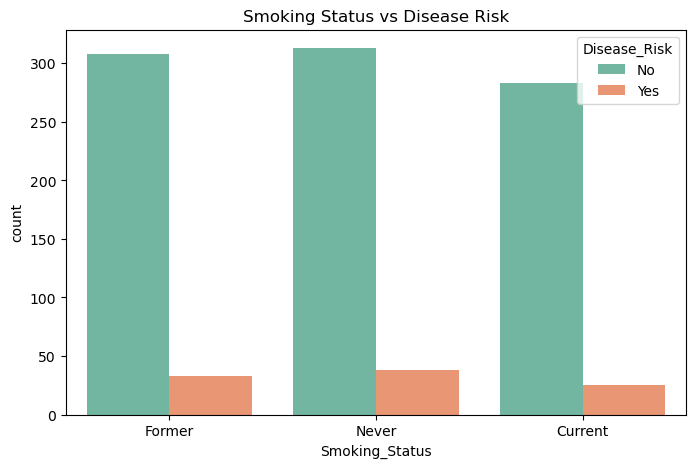

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
#  Bar chart of Smoking_Status vs Disease_Risk
plt.figure(figsize=(8,5))
sns.countplot(x='Smoking_Status', hue='Disease_Risk', data=df, palette='Set2')
plt.title("Smoking Status vs Disease Risk")
plt.show()


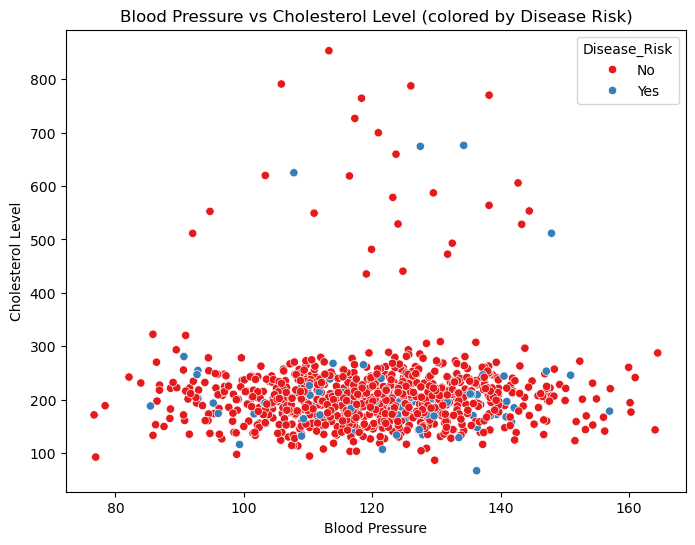

In [59]:
#Scatter plot of Blood Pressure vs Cholesterol colored by Disease Risk
plt.figure(figsize=(8,6))
sns.scatterplot(x='Blood_Pressure', y='Cholesterol_Level',
                hue='Disease_Risk', data=df, palette='Set1')
plt.title("Blood Pressure vs Cholesterol Level (colored by Disease Risk)")
plt.xlabel("Blood Pressure")
plt.ylabel("Cholesterol Level")
plt.show()


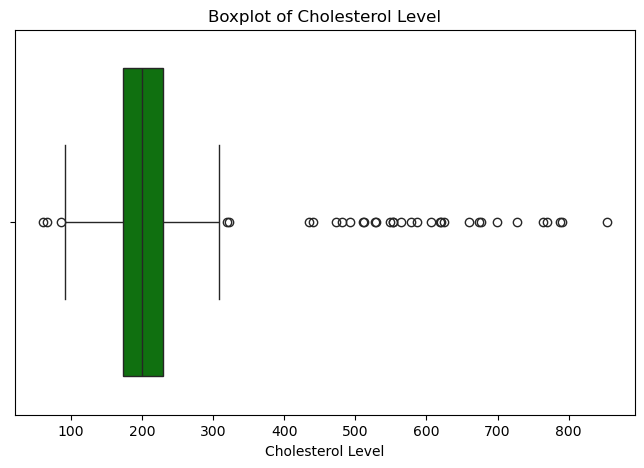

In [60]:
#  Boxplot of Cholesterol_Level to detect outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Cholesterol_Level'], color='green')
plt.title("Boxplot of Cholesterol Level")
plt.xlabel("Cholesterol Level")
plt.show()

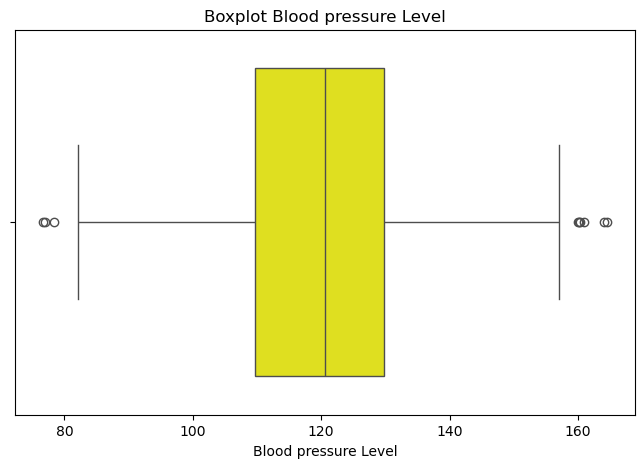

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Blood_Pressure'], color='yellow')
plt.title("Boxplot Blood pressure Level")
plt.xlabel("Blood pressure Level")
plt.show()

In [63]:

# Neumerical and categorical value 
num_features = ["Age","Blood_Pressure","Cholesterol_Level",
                "Hospital_Visits_Per_Year","Wearable_Sensor_Data"]
cat_features = ["Gender","Smoking_Status","Exercise_Level"]
#target = "Disease_Risk"


In [64]:
# ------------------------------
# 4. Encoding categorical variables
# ------------------------------
from sklearn.preprocessing import LabelEncoder
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Encode target variable (Yes/No → 1/0)
#df[target] = df[target].map({"Yes":1,"No":0})
df['Disease_Risk'] = df['Disease_Risk'].map({"No": 0, "Yes": 1})


In [65]:
df.head(10)

,Patient_ID,Age,Gender,Blood_Pressure,Cholesterol_Level,Hospital_Visits_Per_Year,Smoking_Status,Exercise_Level,Medical_Notes,Wearable_Sensor_Data,Disease_Risk
0,1,56,2,114.445149,198.161200,0,1,1,Regular follow-up required,53.992628,0
1,2,69,1,107.496615,154.133411,2,2,2,Regular follow-up required,50.919521,0
2,3,46,0,109.656895,200.219702,3,0,2,No major complaints,70.249713,0
3,4,32,2,127.424333,180.971789,0,2,2,Regular follow-up required,63.268148,0
4,5,60,1,126.273788,195.914862,3,1,1,Stable condition observed,58.079737,1
5,6,25,0,126.006180,216.370336,1,2,1,Patient shows mild symptoms,70.161209,1
6,7,78,2,NaN,156.074181,4,0,2,Patient shows mild symptoms,72.306973,0
7,8,38,2,120.051221,185.527546,5,1,1,Patient shows mild symptoms,61.610316,0
8,9,56,1,132.266290,127.848743,1,2,2,Stable condition observed,63.759153,0
9,10,75,1,97.659104,185.800509,1,2,1,Patient shows mild symptoms,62.379585,0


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                1000 non-null   int64  
 1   Age                       1000 non-null   int64  
 2   Gender                    1000 non-null   int32  
 3   Blood_Pressure            950 non-null    float64
 4   Cholesterol_Level         1000 non-null   float64
 5   Hospital_Visits_Per_Year  1000 non-null   int64  
 6   Smoking_Status            1000 non-null   int32  
 7   Exercise_Level            1000 non-null   int32  
 8   Medical_Notes             1000 non-null   object 
 9   Wearable_Sensor_Data      1000 non-null   float64
 10  Disease_Risk              1000 non-null   int64  
dtypes: float64(3), int32(3), int64(4), object(1)
memory usage: 74.3+ KB


In [67]:
# Define age bins (you can adjust ranges as needed)
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Group by Gender + Age_Group and fill missing Blood_Pressure with median of that group
#
df['Blood_Pressure'] = df.groupby(['Gender','Age_Group'])['Blood_Pressure'].transform(
    lambda x: x.fillna(x.median())
)
df.head(15)

C:\Users\User\AppData\Local\Temp\ipykernel_26320\668963142.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Blood_Pressure'] = df.groupby(['Gender','Age_Group'])['Blood_Pressure'].transform(


,Patient_ID,Age,Gender,Blood_Pressure,Cholesterol_Level,Hospital_Visits_Per_Year,Smoking_Status,Exercise_Level,Medical_Notes,Wearable_Sensor_Data,Disease_Risk,Age_Group
0,1,56,2,114.445149,198.161200,0,1,1,Regular follow-up required,53.992628,0,41-60
1,2,69,1,107.496615,154.133411,2,2,2,Regular follow-up required,50.919521,0,61-80
2,3,46,0,109.656895,200.219702,3,0,2,No major complaints,70.249713,0,41-60
3,4,32,2,127.424333,180.971789,0,2,2,Regular follow-up required,63.268148,0,21-40
4,5,60,1,126.273788,195.914862,3,1,1,Stable condition observed,58.079737,1,61-80
5,6,25,0,126.006180,216.370336,1,2,1,Patient shows mild symptoms,70.161209,1,21-40
6,7,78,2,125.080808,156.074181,4,0,2,Patient shows mild symptoms,72.306973,0,61-80
7,8,38,2,120.051221,185.527546,5,1,1,Patient shows mild symptoms,61.610316,0,21-40
8,9,56,1,132.266290,127.848743,1,2,2,Stable condition observed,63.759153,0,41-60
9,10,75,1,97.659104,185.800509,1,2,1,Patient shows mild symptoms,62.379585,0,61-80


In [68]:
#Missing value count of each features
print(df.isnull().sum())

Patient_ID                  0
Age                         0
Gender                      0
Blood_Pressure              0
Cholesterol_Level           0
Hospital_Visits_Per_Year    0
Smoking_Status              0
Exercise_Level              0
Medical_Notes               0
Wearable_Sensor_Data        0
Disease_Risk                0
Age_Group                   0
dtype: int64


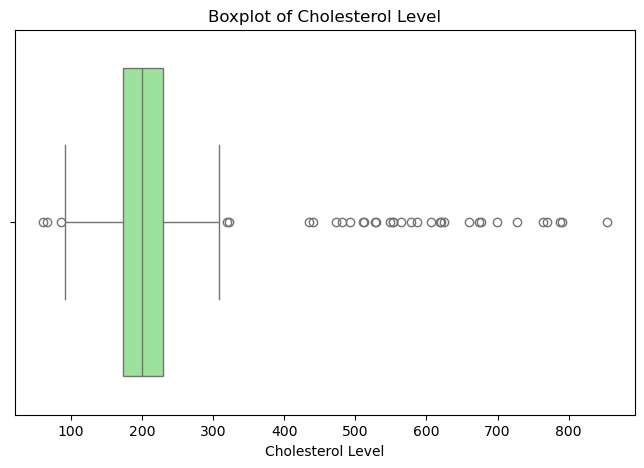

In [69]:
# Identifying outliers 
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Cholesterol_Level'], color='lightgreen')
plt.title("Boxplot of Cholesterol Level")
plt.xlabel("Cholesterol Level")
plt.show()

In [70]:
import numpy as np
Q1 = df["Cholesterol_Level"].quantile(0.25)
Q3 = df["Cholesterol_Level"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df["Cholesterol_Level"] = np.clip(df["Cholesterol_Level"], lower, upper)

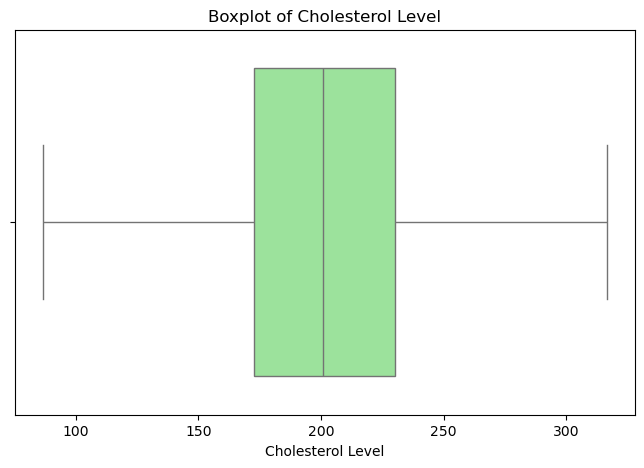

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Cholesterol_Level'], color='lightgreen')
plt.title("Boxplot of Cholesterol Level")
plt.xlabel("Cholesterol Level")
plt.show()

In [72]:
# Checking the class Imbalncing
print("Original class distribution:")
print(df['Disease_Risk'].value_counts())
print(df['Disease_Risk'].value_counts(normalize=True))

Original class distribution:
Disease_Risk
0    904
1     96
Name: count, dtype: int64
Disease_Risk
0    0.904
1    0.096
Name: proportion, dtype: float64


In [73]:
df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Cholesterol_Level,Hospital_Visits_Per_Year,Smoking_Status,Exercise_Level,Medical_Notes,Wearable_Sensor_Data,Disease_Risk,Age_Group
0,1,56,2,114.445149,198.161200,0,1,1,Regular follow-up required,53.992628,0,41-60
1,2,69,1,107.496615,154.133411,2,2,2,Regular follow-up required,50.919521,0,61-80
2,3,46,0,109.656895,200.219702,3,0,2,No major complaints,70.249713,0,41-60
3,4,32,2,127.424333,180.971789,0,2,2,Regular follow-up required,63.268148,0,21-40
4,5,60,1,126.273788,195.914862,3,1,1,Stable condition observed,58.079737,1,61-80


In [74]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X = df.drop(columns=[target,"Patient_ID","Medical_Notes","Age_Group"])  # drop ID & text
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# ------------------------------
#Handle Class Imbalance (SMOTE)
# ------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train,y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Disease_Risk
0    723
1     77
Name: count, dtype: int64
After SMOTE: Disease_Risk
0    723
1    723
Name: count, dtype: int64


In [75]:
# ------------------------------
# 7. Feature Scaling
# ------------------------------
from sklearn.preprocessing import StandardScaler
#from sklearn.feature_selection import SequentialFeatureSelector
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])


In [77]:
print(df[num_features])

          Age  Blood_Pressure  Cholesterol_Level  Hospital_Visits_Per_Year  \
0    0.339295       -0.394243          -0.106602                 -1.470114   
1    1.057320       -0.877218          -1.125832                  0.017103   
2   -0.213033       -0.727062          -0.058948                  0.760711   
3   -0.986291        0.507907          -0.504532                 -1.470114   
4    0.560226        0.427936          -0.158604                  0.760711   
..        ...             ...                ...                       ...   
995 -1.759549       -1.241972          -0.569864                  0.017103   
996 -0.820593       -1.706439           1.066815                  1.504320   
997 -0.047334        1.318571          -0.515137                  0.017103   
998  0.781156        1.963844           1.259311                 -0.726505   
999  0.891622       -0.489926          -0.633471                 -0.726505   

     Wearable_Sensor_Data  
0               -1.539415  
1      

In [78]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)

def evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test,y_pred)

results = {}

In [80]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SelectKBest
from sklearn.metrics import f1_score
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.decomposition import PCA
# ------------------------------
# 11. No Feature Selection
# ------------------------------
results["No Feature Selection"] = evaluate_model(X_train_res,y_train_res,X_test,y_test,log_reg)

# ------------------------------
# 12. Variance Threshold
# ------------------------------
selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train_res)
X_test_var = selector.transform(X_test)
results["Variance Threshold"] = evaluate_model(X_train_var,y_train_res,X_test_var,y_test,log_reg)

# ------------------------------
# 13. Information Gain
# ------------------------------
selector = SelectKBest(mutual_info_classif,k=5)
X_train_ig = selector.fit_transform(X_train_res,y_train_res)
X_test_ig = selector.transform(X_test)
results["Information Gain"] = evaluate_model(X_train_ig,y_train_res,X_test_ig,y_test,log_reg)

# ------------------------------
# 14. Forward Feature Selection
# ------------------------------
sfs = SequentialFeatureSelector(log_reg,n_features_to_select=5,direction="forward")
sfs.fit(X_train_res,y_train_res)
X_train_fs = sfs.transform(X_train_res)
X_test_fs = sfs.transform(X_test)
results["Forward Selection"] = evaluate_model(X_train_fs,y_train_res,X_test_fs,y_test,log_reg)

# ------------------------------
# 15. PCA
# ------------------------------
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_res)
X_test_pca = pca.transform(X_test)
results["PCA"] = evaluate_model(X_train_pca,y_train_res,X_test_pca,y_test,log_reg)

# ------------------------------
# 16. Comparative Results
# ------------------------------
print("F1-Score Comparison:")
for method, score in results.items():
    print(f"{method}: {score:.4f}")


F1-Score Comparison:
No Feature Selection: 0.1667
Variance Threshold: 0.1667
Information Gain: 0.1414
Forward Selection: 0.1682
PCA: 0.1239


In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=1),
        "Recall": recall_score(y_test, y_pred, pos_label=1),
        "F1": f1_score(y_test, y_pred, pos_label=1)
    }


In [86]:
results["Variance Threshold"] = evaluate_model(X_train_var, y_train_res, X_test_var, y_test, log_reg)


In [93]:
print("Model Performance Comparison:")
for method, metrics in results.items():
    print(f"\n{method}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


Model Performance Comparison:

No Feature Selection:
  Accuracy: 0.5500
  Precision: 0.1011
  Recall: 0.4737
  F1: 0.1667

Variance Threshold:
  Accuracy: 0.5500
  Precision: 0.1011
  Recall: 0.4737
  F1: 0.1667

Information Gain:
  Accuracy: 0.5750
  Precision: 0.0875
  Recall: 0.3684
  F1: 0.1414

Forward Selection:
  Accuracy: 0.5550
  Precision: 0.1023
  Recall: 0.4737
  F1: 0.1682

PCA:
  Accuracy: 0.5050
  Precision: 0.0745
  Recall: 0.3684
  F1: 0.1239


In [91]:
methods = {
    "No Feature Selection": (X_train_res, X_test),
    "Variance Threshold": (X_train_var, X_test_var),
    "Information Gain": (X_train_ig, X_test_ig),
    "Forward Selection": (X_train_fs, X_test_fs),
    "PCA": (X_train_pca, X_test_pca)
}

results = {}

for method, (Xtr, Xte) in methods.items():
    try:
        results[method] = evaluate_model(Xtr, y_train_res, Xte, y_test, log_reg)
    except Exception as e:
        print(f"{method} failed: {e}")


In [94]:
import pandas as pd

# Convert results dictionary into a DataFrame
results_df = pd.DataFrame(results).T   # .T transposes so methods are rows

# Print the table
print("\nModel Performance Comparison (Tabular Format):")
print(results_df.to_string(float_format="%.4f"))



Model Performance Comparison (Tabular Format):
                      Accuracy  Precision  Recall     F1
No Feature Selection    0.5500     0.1011  0.4737 0.1667
Variance Threshold      0.5500     0.1011  0.4737 0.1667
Information Gain        0.5750     0.0875  0.3684 0.1414
Forward Selection       0.5550     0.1023  0.4737 0.1682
PCA                     0.5050     0.0745  0.3684 0.1239


In [95]:
import pandas as pd
from tabulate import tabulate

# Convert results dictionary into a DataFrame
results_df = pd.DataFrame(results).T

# Print as a nice table
print("\nModel Performance Comparison (Tabular Format):")
print(tabulate(results_df, headers="keys", tablefmt="fancy_grid", floatfmt=".4f"))



Model Performance Comparison (Tabular Format):
╒══════════════════════╤════════════╤═════════════╤══════════╤════════╕
│                      │   Accuracy │   Precision │   Recall │     F1 │
╞══════════════════════╪════════════╪═════════════╪══════════╪════════╡
│ No Feature Selection │     0.5500 │      0.1011 │   0.4737 │ 0.1667 │
├──────────────────────┼────────────┼─────────────┼──────────┼────────┤
│ Variance Threshold   │     0.5500 │      0.1011 │   0.4737 │ 0.1667 │
├──────────────────────┼────────────┼─────────────┼──────────┼────────┤
│ Information Gain     │     0.5750 │      0.0875 │   0.3684 │ 0.1414 │
├──────────────────────┼────────────┼─────────────┼──────────┼────────┤
│ Forward Selection    │     0.5550 │      0.1023 │   0.4737 │ 0.1682 │
├──────────────────────┼────────────┼─────────────┼──────────┼────────┤
│ PCA                  │     0.5050 │      0.0745 │   0.3684 │ 0.1239 │
╘══════════════════════╧════════════╧═════════════╧══════════╧════════╛


In [96]:
import pandas as pd

results_df = pd.DataFrame(results).T

# Apply styling
styled = results_df.style\
    .set_caption("Model Performance Comparison")\
    .background_gradient(cmap="Blues")\
    .highlight_max(axis=0, color="lightgreen")\
    .format("{:.4f}")

styled


,Accuracy,Precision,Recall,F1
No Feature Selection,0.5500,0.1011,0.4737,0.1667
Variance Threshold,0.5500,0.1011,0.4737,0.1667
Information Gain,0.5750,0.0875,0.3684,0.1414
Forward Selection,0.5550,0.1023,0.4737,0.1682
PCA,0.5050,0.0745,0.3684,0.1239


<Figure size 1000x600 with 0 Axes>

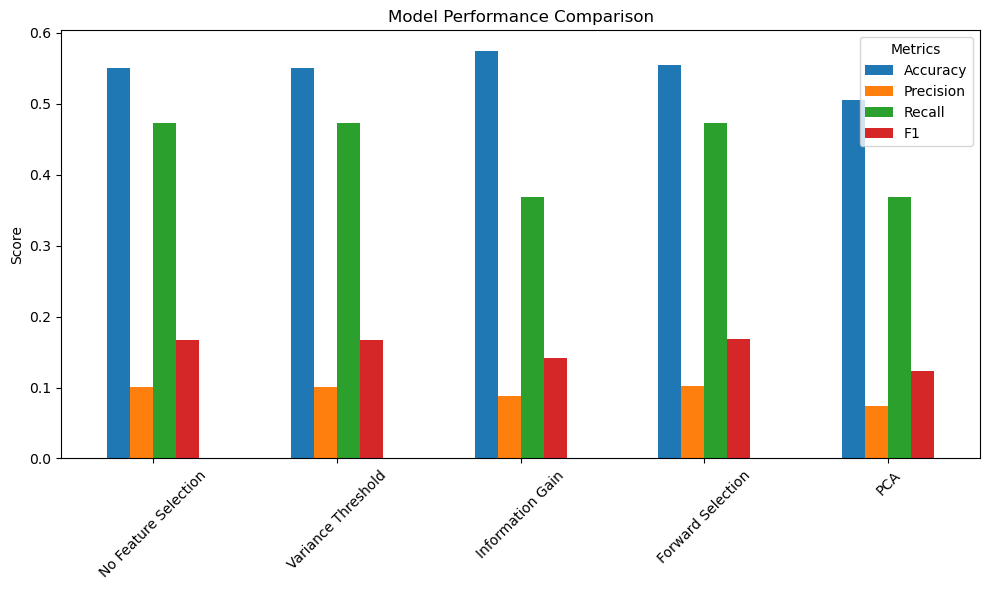

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results dictionary into DataFrame
results_df = pd.DataFrame(results).T

# Plot grouped bar chart
plt.figure(figsize=(10,6))
results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


In [102]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = log_reg.predict(X_test_fs)    # if Forward Selection

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       181
           1       0.10      1.00      0.17        19

    accuracy                           0.10       200
   macro avg       0.05      0.50      0.09       200
weighted avg       0.01      0.10      0.02       200

[[  0 181]
 [  0  19]]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [100]:
y_pred = log_reg.predict(X_test_pca)   # if PCA
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.52      0.66       181
           1       0.07      0.37      0.12        19

    accuracy                           0.51       200
   macro avg       0.48      0.44      0.39       200
weighted avg       0.81      0.51      0.60       200

[[94 87]
 [12  7]]


In [101]:
y_pred = log_reg.predict(X_test_ig)    # if Information Gain
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      1.00      0.95       181
           1       0.00      0.00      0.00        19

    accuracy                           0.91       200
   macro avg       0.45      0.50      0.48       200
weighted avg       0.82      0.91      0.86       200

[[181   0]
 [ 19   0]]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
